#  PPO WITH PRECEDENCE NETWORK — CartPole-v1

Trains PPO using the World Model (Precedence Network) to **verify actions BEFORE execution**.

✅ Tests the 3 World Model configurations:
- **Config 1** : S(t+1) direct  
- **Config 2** : S(t+5) direct (greedy rollout via Config 1 auxiliary model)  
- **Config 3** : ΔS = S(t+1) − S(t)

✅ ActionVerifier: same verification strategies as DQN version  
✅ PPO Actor-Critic with separate networks (same architecture as ppo_agent.py baseline)  
✅ GAE-λ advantages, KL early stopping, entropy bonus  
✅ Comparison across configs

## 1. Imports & Setup

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import gymnasium as gym
import scipy.signal
import json
from datetime import datetime


ENV_NAME        = "CartPole-v1"
DATA_PATH       = "../data/collected/CartPole"
CHECKPOINT_DIR  = "checkpoints_ppo_with_precedence"
PLOT_DIR        = "plots_ppo_with_precedence"
WORLD_MODEL_DIR = "world_model/checkpoints_CartPole"


STEPS_PER_EPOCH          = 4_000
EPOCHS                   = 30
HIDDEN_SIZES             = (64, 64)
POLICY_LR                = 3e-4
VALUE_LR                 = 1e-3
TRAIN_POLICY_ITERATIONS  = 80
TRAIN_VALUE_ITERATIONS   = 80
GAMMA                    = 0.99
LAM                      = 0.97
CLIP_RATIO               = 0.2
TARGET_KL                = 0.01
ENTROPY_COEF             = 0.0    

STATE_DIM  = 4
ACTION_DIM = 2

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,       exist_ok=True)

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f" Setup OK")
print(f"  Device      : {DEVICE}")
print(f"  Environment : {ENV_NAME}")
print(f"  Steps/epoch : {STEPS_PER_EPOCH}  |  Epochs: {EPOCHS}")
print(f"  γ={GAMMA}  λ={LAM}  clip={CLIP_RATIO}  target_kl={TARGET_KL}")


✅ Setup OK
  Device      : cpu
  Environment : CartPole-v1
  Steps/epoch : 4000  |  Epochs: 30
  γ=0.99  λ=0.97  clip=0.2  target_kl=0.01


## 2. Load Normalisation Stats

In [2]:
scaler_path = os.path.join(DATA_PATH, "scaler.npz")
scaler      = np.load(scaler_path, allow_pickle=True)

STATE_MEAN = scaler["state_mean"].astype(np.float32)
STATE_STD  = scaler["state_std"].astype(np.float32)

print(f"📦 Scaler loaded")
print(f"  State mean : {STATE_MEAN}")
print(f"  State std  : {STATE_STD}")


📦 Scaler loaded
  State mean : [-0.00020712 -0.02029223  0.00405843  0.02626351]
  State std  : [0.48820907 0.80932426 0.12245946 0.66561514]


## 3. World Model Architecture (load)

In [ ]:
class WorldModel(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int,
                 config: int = 1, n_step: int = 5, hidden: int = 64):
        super().__init__()
        assert config in (1, 2, 3)
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.config  = config
        self.n_step  = n_step

        in_dim = obs_dim + (n_step * act_dim if config == 2 else act_dim)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, obs_dim),
        )

    def forward(self, state, action_input):
        return self.net(torch.cat([state, action_input], dim=-1))

    def predict(self, state, action_input):
        out = self.forward(state, action_input)
        return state + out if self.config == 3 else out


def load_world_model(config: int, checkpoint_dir: str = WORLD_MODEL_DIR):
    model = WorldModel(STATE_DIM, ACTION_DIM, config=config,
                       n_step=5, hidden=64).to(DEVICE)
    ckpt_path = os.path.join(checkpoint_dir, f"wm_{ENV_NAME}_config{config}.pt")
    if config == 2:
        ckpt_path = os.path.join(checkpoint_dir, f"wm_{ENV_NAME}_config{config}_n5.pt")

    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt["state_dict"])
        model.eval()
        print(f"✅ Config {config} world model loaded: {ckpt_path}")
        return model
    else:
        print(f"❌ File not found: {ckpt_path}")
        return None


print("✅ WorldModel architecture defined")


✅ WorldModel architecture defined


## 4. ActionVerifier — Verification Strategies

**Config 2 — Greedy rollout:**  
To build the `[a0 | a1 | ... | a4]` vector required by Config 2, we simulate the future trajectory:
- `a0` = action being verified  
- `a1…a4` = greedy actions from the PPO **Actor** on successive states predicted by the **Config 1 auxiliary World Model**

This is the same approach as the DQN version — only the policy used for greedy actions changes (Actor logits argmax instead of Q-network argmax).

In [ ]:
class ActionVerifier:
    """
    Verifies whether an action is 'good' by predicting the next state
    with the World Model (Precedence Network).

    For Config 2, uses a greedy rollout:
      a0 = candidate action
      a1…a_{n-1} = greedy actions from the PPO Actor on simulated states
                   propagated via the Config 1 auxiliary world model
    """

    def __init__(self, world_model: WorldModel, config: int,
                 safety_threshold: float = 0.3,
                 stability_threshold: float = 0.5,
                 aux_model: WorldModel = None,
                 actor: nn.Module = None):
        self.model               = world_model
        self.config              = config
        self.safety_threshold    = safety_threshold
        self.stability_threshold = stability_threshold
        self.aux_model           = aux_model
        self.actor               = actor 


        self.pole_angle_safe_bound    = 0.2 
        self.cart_position_safe_bound = 2.0



    @torch.no_grad()
    def _build_action_sequence_config2(self, state_t: torch.Tensor,
                                       first_action: int) -> torch.Tensor:
        """
        Builds the action vector [a0|a1|...|a_{n-1}] for Config 2
        via greedy PPO Actor rollout + Config 1 auxiliary world model.

        Args:
            state_t      : current state (1, STATE_DIM), normalised
            first_action : candidate action to verify (a0)

        Returns:
            action_input : (1, n_step * ACTION_DIM)
        """
        n_step     = self.model.n_step
        actions_seq = []
        state_loop  = state_t.clone()

        for step in range(n_step):
            if step == 0:
                a = first_action
            elif self.actor is not None:

                logits = self.actor(state_loop)
                a = int(logits.argmax(dim=-1).item())
            else:
                a = first_action  

            a_oh = torch.zeros(ACTION_DIM, device=DEVICE)
            a_oh[a] = 1.0
            actions_seq.append(a_oh)

            if step < n_step - 1:
                if self.aux_model is not None:
                    state_loop = self.aux_model.predict(state_loop, a_oh.unsqueeze(0))

        return torch.cat(actions_seq).unsqueeze(0) 

 
    @torch.no_grad()
    def predict_next_state(self, state_np: np.ndarray, action: int) -> tuple:
        state_t = torch.FloatTensor(state_np).unsqueeze(0).to(DEVICE)

        if self.config == 2:
            action_input = self._build_action_sequence_config2(state_t, action)
        else:
            action_input = torch.zeros(1, ACTION_DIM, device=DEVICE)
            action_input[0, action] = 1.0

        predicted_state_t  = self.model.predict(state_t, action_input)
        predicted_state_np = predicted_state_t.cpu().numpy()[0]
        return predicted_state_np, 0.0


    @torch.no_grad()
    def verify_action_cartpole(self, state_np: np.ndarray, action: int,
                                strategy: str = 'combined') -> tuple:
        details = {
            'strategy'       : strategy,
            'predicted_state': None,
            'pole_angle'     : None,
            'cart_position'  : None,
            'safety_ok'      : False,
            'stability_ok'   : False,
            'is_valid'       : False,
            'confidence'     : 0.0,
        }

        predicted_state, _ = self.predict_next_state(state_np, action)
        pole_angle    = abs(predicted_state[2])
        cart_position = abs(predicted_state[0])
        safety_ok     = (pole_angle    < self.pole_angle_safe_bound and
                         cart_position < self.cart_position_safe_bound)

        details.update({
            'predicted_state': predicted_state,
            'pole_angle'     : float(pole_angle),
            'cart_position'  : float(cart_position),
            'safety_ok'      : bool(safety_ok),
        })

        if strategy in ['safety', 'combined'] and not safety_ok:
            details['is_valid']   = False
            details['confidence'] = 0.0
            return False, 0.0, details

        variance     = 0.0
        stability_ok = True

        if strategy in ['stability', 'combined']:
            predictions = []
            for i in range(5):
                noise_scale    = 0.01 if i > 0 else 0.0
                perturbed      = state_np + np.random.randn(STATE_DIM) * noise_scale
                pred, _        = self.predict_next_state(perturbed, action)
                predictions.append(pred)

            predictions_arr = np.array(predictions)
            variance        = float(np.mean(np.var(predictions_arr, axis=0)))
            stability_ok    = variance < self.stability_threshold

            details['stability_ok']        = bool(stability_ok)
            details['prediction_variance'] = variance

            if not stability_ok and strategy == 'stability':
                details['is_valid']   = False
                details['confidence'] = 0.5
                return False, 0.5, details

        if strategy == 'safety':
            is_valid   = safety_ok
            confidence = 1.0 if is_valid else 0.0
        elif strategy == 'stability':
            is_valid   = stability_ok
            confidence = 1.0 - min(variance / self.stability_threshold, 1.0)
        else:  
            is_valid     = safety_ok
            safety_score = 1.0 if safety_ok else 0.0
            stab_score   = (1.0 - min(variance / self.stability_threshold, 1.0)
                            if 'prediction_variance' in details else 0.5)
            confidence   = (safety_score + stab_score) / 2.0

        details['is_valid']   = bool(is_valid)
        details['confidence'] = float(confidence)
        return is_valid, confidence, details


print("✅ ActionVerifier defined (Config 2: greedy PPO Actor + aux WM rollout)")


✅ ActionVerifier defined (Config 2: greedy PPO Actor + aux WM rollout)


## 5. PPO Actor-Critic Networks

In [ ]:
def build_mlp(in_dim: int, hidden_sizes: tuple, out_dim: int,
              activation=nn.Tanh) -> nn.Sequential:
    layers, prev = [], in_dim
    for h in hidden_sizes:
        layers += [nn.Linear(prev, h), activation()]
        prev = h
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)


class Actor(nn.Module):
    def __init__(self, obs_dim: int, n_act: int,
                 hidden: tuple = HIDDEN_SIZES):
        super().__init__()
        self.net = build_mlp(obs_dim, hidden, n_act)

    def forward(self, obs):
        return self.net(obs)

    def logprobabilities(self, obs, actions):
        logits    = self(obs)
        log_probs = torch.log_softmax(logits, dim=-1)
        return log_probs.gather(1, actions.unsqueeze(1)).squeeze(1)

    @torch.no_grad()
    def sample_action(self, obs):
        logits   = self(obs)
        action   = torch.distributions.Categorical(logits=logits).sample()
        log_probs= torch.log_softmax(logits, dim=-1)
        logp     = log_probs.gather(1, action.unsqueeze(1)).squeeze(1)
        return action, logp


class Critic(nn.Module):
    def __init__(self, obs_dim: int, hidden: tuple = HIDDEN_SIZES):
        super().__init__()
        self.net = build_mlp(obs_dim, hidden, 1)

    def forward(self, obs):
        return self.net(obs).squeeze(-1)


print("✅ Actor-Critic networks defined")


✅ Actor-Critic networks defined


## 6. GAE Buffer

In [ ]:
def discounted_cumulative_sums(x, discount):
    return scipy.signal.lfilter([1], [1, float(-discount)], x[::-1], axis=0)[::-1]


class Buffer:

    def __init__(self, obs_dim: int, size: int,
                 gamma: float, lam: float):
        self.obs_buf  = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf  = np.zeros(size,            dtype=np.int32)
        self.adv_buf  = np.zeros(size,            dtype=np.float32)
        self.rew_buf  = np.zeros(size,            dtype=np.float32)
        self.ret_buf  = np.zeros(size,            dtype=np.float32)
        self.val_buf  = np.zeros(size,            dtype=np.float32)
        self.logp_buf = np.zeros(size,            dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.ptr, self.traj_start = 0, 0

    def store(self, obs, action, reward, value, logp):
        self.obs_buf [self.ptr] = obs
        self.act_buf [self.ptr] = action
        self.rew_buf [self.ptr] = reward
        self.val_buf [self.ptr] = value
        self.logp_buf[self.ptr] = logp
        self.ptr += 1

    def finish_trajectory(self, last_value: float = 0.0):
        path    = slice(self.traj_start, self.ptr)
        rewards = np.append(self.rew_buf[path], last_value)
        values  = np.append(self.val_buf[path], last_value)
        deltas  = rewards[:-1] + self.gamma * values[1:] - values[:-1]
        self.adv_buf[path] = discounted_cumulative_sums(deltas, self.gamma * self.lam)
        self.ret_buf[path] = discounted_cumulative_sums(rewards, self.gamma)[:-1]
        self.traj_start    = self.ptr

    def get(self):
        self.ptr, self.traj_start = 0, 0
        adv_mean = self.adv_buf.mean()
        adv_std  = self.adv_buf.std() + 1e-8
        self.adv_buf = (self.adv_buf - adv_mean) / adv_std
        return (self.obs_buf, self.act_buf, self.adv_buf,
                self.ret_buf, self.logp_buf)


print("✅ GAE Buffer defined")


✅ GAE Buffer defined


## 7. PPO Update Functions

In [ ]:
def train_policy(actor, policy_optimizer, obs_t, act_t,
                 logp_old_t, adv_t,
                 clip_ratio: float = CLIP_RATIO,
                 target_kl: float  = TARGET_KL,
                 entropy_coef: float = ENTROPY_COEF) -> float:
    policy_optimizer.zero_grad()
    logits   = actor(obs_t)
    dist     = torch.distributions.Categorical(logits=logits)
    logp_new = dist.log_prob(act_t)
    entropy  = dist.entropy().mean()

    ratio    = torch.exp(logp_new - logp_old_t)
    clip_adv = torch.where(adv_t > 0,
                           (1 + clip_ratio) * adv_t,
                           (1 - clip_ratio) * adv_t)
    policy_loss = -torch.mean(torch.minimum(ratio * adv_t, clip_adv))
    loss = policy_loss - entropy_coef * entropy

    loss.backward()
    nn.utils.clip_grad_norm_(actor.parameters(), max_norm=0.5)
    policy_optimizer.step()

    with torch.no_grad():
        logp_after = actor.logprobabilities(obs_t, act_t)
        kl = torch.mean(logp_old_t - logp_after)
    return kl.item()


def train_value_function(critic, value_optimizer, obs_t, ret_t) -> float:
    value_optimizer.zero_grad()
    loss = torch.mean((ret_t - critic(obs_t)) ** 2)
    loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), max_norm=0.5)
    value_optimizer.step()
    return loss.item()


print("✅ PPO update functions defined")


✅ PPO update functions defined


## 8. Training Loop

**Key difference from the DQN version:**  
PPO collects `STEPS_PER_EPOCH` steps before each update (on-policy rollout), 
rather than sampling from a replay buffer after each step.  
Action verification happens **inside the rollout collection** — the verified action 
is what gets stored in the buffer and executed in the environment.

In [ ]:
def train_ppo_with_config(config: int,
                          use_precedence: bool = True,
                          verify_strategy: str = 'combined'):

    print(f"\n{'='*80}")
    print(f"  PPO Training — Config {config} | Use Precedence: {use_precedence}")
    print(f"  Environment : {ENV_NAME}")
    if use_precedence:
        print(f"  Verification Strategy : {verify_strategy}")
        if config == 2:
            print(f"  Config 2 : greedy rollout (PPO Actor + aux WM Config 1)")
    print(f"{'='*80}\n")

    env     = gym.make(ENV_NAME)
    obs_dim = env.observation_space.shape[0]
    n_act   = env.action_space.n

    actor   = Actor(obs_dim,  n_act, HIDDEN_SIZES).to(DEVICE)
    critic  = Critic(obs_dim, HIDDEN_SIZES).to(DEVICE)
    policy_optimizer = optim.Adam(actor.parameters(),  lr=POLICY_LR)
    value_optimizer  = optim.Adam(critic.parameters(), lr=VALUE_LR)
    buffer  = Buffer(obs_dim, STEPS_PER_EPOCH, GAMMA, LAM)

    world_model = load_world_model(config) if use_precedence else None
    if use_precedence and world_model is None:
        print(f"❌ Cannot load world model for config {config}")
        return None

    aux_model = None
    if use_precedence and config == 2:
        aux_model = load_world_model(1)
        if aux_model is None:
            print("⚠️  Auxiliary Config 1 model not found — degraded rollout (state frozen)")

    verifier = None
    if use_precedence:
        verifier = ActionVerifier(
            world_model=world_model,
            config=config,
            safety_threshold=0.3,
            stability_threshold=0.5,
            aux_model=aux_model,
            actor=actor,        
        )

    all_rewards   = []
    mean_rewards  = []
    verified_hist = [] 
    skipped_hist  = []
    verification_history = []

    actions_verified        = 0
    actions_skipped         = 0

    observation, _ = env.reset(seed=SEED)
    obs_norm       = (observation - STATE_MEAN) / (STATE_STD + 1e-8)

    ep_return, ep_length = 0.0, 0
    ep_verified, ep_skipped = 0, 0
    num_episodes_total = 0

    for epoch in range(EPOCHS):
        sum_return   = 0.0
        sum_length   = 0
        num_ep_epoch = 0

        for t in range(STEPS_PER_EPOCH):
            obs_t = torch.tensor(obs_norm, dtype=torch.float32,
                                 device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                action_t, logp_t = actor.sample_action(obs_t)
                value_t          = critic(obs_t)

            action = int(action_t.item())
            logp   = logp_t.item()
            value  = value_t.item()

            if use_precedence and verifier is not None:
                if config == 2:
                    verifier.actor = actor

                is_valid, confidence, details = verifier.verify_action_cartpole(
                    obs_norm, action, strategy=verify_strategy
                )
                details['recommended_action'] = action
                verification_history.append(details)

                if not is_valid:
                    alt = 1 - action  
                    is_valid_alt, conf_alt, details_alt = verifier.verify_action_cartpole(
                        obs_norm, alt, strategy=verify_strategy
                    )
                    if is_valid_alt:
                        action = alt
                        logp_t2 = actor.logprobabilities(
                            obs_t,
                            torch.tensor([action], dtype=torch.int64, device=DEVICE)
                        )
                        logp  = logp_t2.item()
                        details_alt['recommended_action'] = int(action_t.item())
                        details_alt['alternative_action'] = alt
                        verification_history[-1] = details_alt
                        ep_verified += 1
                        actions_verified += 1
                    else:
                        ep_skipped += 1
                        actions_skipped += 1
                else:
                    ep_verified += 1
                    actions_verified += 1

            observation_new, reward, terminated, truncated, _ = env.step(action)
            done    = terminated or truncated
            obs_norm_new = (observation_new - STATE_MEAN) / (STATE_STD + 1e-8)

            ep_return += reward
            ep_length += 1

            buffer.store(obs_norm, action, reward, value, logp)
            obs_norm = obs_norm_new

            terminal = done or (t == STEPS_PER_EPOCH - 1)
            if terminal:
                if done:
                    last_value = 0.0
                else:
                    obs_boot = torch.tensor(obs_norm, dtype=torch.float32,
                                            device=DEVICE).unsqueeze(0)
                    with torch.no_grad():
                        last_value = critic(obs_boot).item()

                buffer.finish_trajectory(last_value)
                sum_return   += ep_return
                sum_length   += ep_length
                num_ep_epoch += 1
                num_episodes_total += 1

                all_rewards.append(ep_return)
                mean_rewards.append(np.mean(all_rewards[-25:]))
                verified_hist.append(ep_verified)
                skipped_hist.append(ep_skipped)

                observation, _ = env.reset(seed=SEED + num_episodes_total)
                obs_norm       = (observation - STATE_MEAN) / (STATE_STD + 1e-8)
                ep_return, ep_length   = 0.0, 0
                ep_verified, ep_skipped = 0, 0

        obs_b, act_b, adv_b, ret_b, logp_b = buffer.get()

        obs_t  = torch.tensor(obs_b,  dtype=torch.float32, device=DEVICE)
        act_t  = torch.tensor(act_b,  dtype=torch.int64,   device=DEVICE)
        adv_t  = torch.tensor(adv_b,  dtype=torch.float32, device=DEVICE)
        ret_t  = torch.tensor(ret_b,  dtype=torch.float32, device=DEVICE)
        logp_t = torch.tensor(logp_b, dtype=torch.float32, device=DEVICE)

        for pi_iter in range(TRAIN_POLICY_ITERATIONS):
            kl = train_policy(actor, policy_optimizer,
                              obs_t, act_t, logp_t, adv_t)
            if kl > 1.5 * TARGET_KL:
                print(f"   [KL early stop] epoch={epoch+1} iter={pi_iter+1} kl={kl:.5f}")
                break

        for _ in range(TRAIN_VALUE_ITERATIONS):
            train_value_function(critic, value_optimizer, obs_t, ret_t)

        mean_ret = sum_return   / max(num_ep_epoch, 1)
        mean_len = sum_length   / max(num_ep_epoch, 1)
        print(f"Epoch {epoch+1:03d}/{EPOCHS}  "
              f"MeanReturn={mean_ret:8.2f}  "
              f"MeanLen={mean_len:5.1f}  "
              f"Episodes={num_ep_epoch:3d}  "
              f"TotalEps={num_episodes_total}", end="")
        if use_precedence:
            ep_v = sum(verified_hist[-num_ep_epoch:]) / max(num_ep_epoch, 1) if verified_hist else 0
            ep_s = sum(skipped_hist [-num_ep_epoch:]) / max(num_ep_epoch, 1) if skipped_hist  else 0
            print(f"  Verified/ep={ep_v:.1f}  Skipped/ep={ep_s:.1f}")
        else:
            print()

    env.close()

    eval_rewards = []
    eval_env     = gym.make(ENV_NAME)
    actor.eval()
    for i in range(10):
        obs_e, _ = eval_env.reset(seed=SEED + 200 + i)
        ep_r, done_e = 0.0, False
        while not done_e:
            with torch.no_grad():
                obs_t = torch.tensor(
                    (obs_e - STATE_MEAN) / (STATE_STD + 1e-8),
                    dtype=torch.float32, device=DEVICE).unsqueeze(0)
                a_e = int(actor(obs_t).argmax(dim=-1).item())
            obs_e, r_e, term_e, trunc_e, _ = eval_env.step(a_e)
            done_e = term_e or trunc_e
            ep_r  += r_e
        eval_rewards.append(ep_r)
    eval_env.close()
    actor.train()
    print(f"[Eval] Greedy mean reward (10 eps) = {np.mean(eval_rewards):.2f}  "
          f"(min={min(eval_rewards):.0f}, max={max(eval_rewards):.0f})")

    return {
        'config'               : config,
        'use_precedence'       : use_precedence,
        'actor'                : actor,
        'critic'               : critic,
        'rewards'              : all_rewards,
        'mean_rewards'         : mean_rewards,
        'verified'             : verified_hist,
        'skipped'              : skipped_hist,
        'verification_history' : verification_history,
        'actions_verified'     : actions_verified,
        'actions_skipped'      : actions_skipped,
        'eval_rewards'         : eval_rewards,
    }


print(" PPO training function defined")


✅ PPO training function defined


## 9. Train — Config 1 (S(t+1) direct)

In [9]:
results_config1 = train_ppo_with_config(
    config=1,
    use_precedence=True,
    verify_strategy='combined'
)



  PPO Training — Config 1 | Use Precedence: True
  Environment : CartPole-v1
  Verification Strategy : combined

✅ Config 1 world model loaded: world_model/checkpoints_CartPole/wm_CartPole-v1_config1.pt
   [KL early stop] epoch=1 iter=12 kl=0.01584
Epoch 001/30  MeanReturn=   21.28  MeanLen= 21.3  Episodes=188  TotalEps=188  Verified/ep=5.0  Skipped/ep=16.2
Epoch 002/30  MeanReturn=   30.77  MeanLen= 30.8  Episodes=130  TotalEps=318  Verified/ep=7.1  Skipped/ep=23.7
   [KL early stop] epoch=3 iter=15 kl=0.01537
Epoch 003/30  MeanReturn=   44.44  MeanLen= 44.4  Episodes= 90  TotalEps=408  Verified/ep=9.8  Skipped/ep=34.7
   [KL early stop] epoch=4 iter=17 kl=0.01529
Epoch 004/30  MeanReturn=   74.07  MeanLen= 74.1  Episodes= 54  TotalEps=462  Verified/ep=13.2  Skipped/ep=60.9
Epoch 005/30  MeanReturn=  137.93  MeanLen=137.9  Episodes= 29  TotalEps=491  Verified/ep=32.8  Skipped/ep=105.1
Epoch 006/30  MeanReturn=  235.29  MeanLen=235.3  Episodes= 17  TotalEps=508  Verified/ep=63.9  Skip

## 10. Train — Config 2 (S(t+5) direct — greedy PPO Actor rollout)

In [10]:
results_config2 = train_ppo_with_config(
    config=2,
    use_precedence=True,
    verify_strategy='combined'
)



  PPO Training — Config 2 | Use Precedence: True
  Environment : CartPole-v1
  Verification Strategy : combined
  Config 2 : greedy rollout (PPO Actor + aux WM Config 1)

✅ Config 2 world model loaded: world_model/checkpoints_CartPole/wm_CartPole-v1_config2_n5.pt
✅ Config 1 world model loaded: world_model/checkpoints_CartPole/wm_CartPole-v1_config1.pt
Epoch 001/30  MeanReturn=  133.33  MeanLen=133.3  Episodes= 30  TotalEps=30  Verified/ep=113.4  Skipped/ep=20.0
Epoch 002/30  MeanReturn=   50.63  MeanLen= 50.6  Episodes= 79  TotalEps=109  Verified/ep=30.7  Skipped/ep=19.9
Epoch 003/30  MeanReturn=   88.89  MeanLen= 88.9  Episodes= 45  TotalEps=154  Verified/ep=59.4  Skipped/ep=29.5
Epoch 004/30  MeanReturn=  125.00  MeanLen=125.0  Episodes= 32  TotalEps=186  Verified/ep=90.7  Skipped/ep=34.3
Epoch 005/30  MeanReturn=  222.22  MeanLen=222.2  Episodes= 18  TotalEps=204  Verified/ep=165.8  Skipped/ep=56.4
Epoch 006/30  MeanReturn=  235.29  MeanLen=235.3  Episodes= 17  TotalEps=221  Verifi

## 11. Train — Config 3 (ΔS)

In [11]:
results_config3 = train_ppo_with_config(
    config=3,
    use_precedence=True,
    verify_strategy='combined'
)



  PPO Training — Config 3 | Use Precedence: True
  Environment : CartPole-v1
  Verification Strategy : combined

✅ Config 3 world model loaded: world_model/checkpoints_CartPole/wm_CartPole-v1_config3.pt
   [KL early stop] epoch=1 iter=11 kl=0.01598
Epoch 001/30  MeanReturn=   22.22  MeanLen= 22.2  Episodes=180  TotalEps=180  Verified/ep=5.0  Skipped/ep=17.2
Epoch 002/30  MeanReturn=   33.06  MeanLen= 33.1  Episodes=121  TotalEps=301  Verified/ep=6.2  Skipped/ep=26.9
Epoch 003/30  MeanReturn=   46.51  MeanLen= 46.5  Episodes= 86  TotalEps=387  Verified/ep=8.0  Skipped/ep=38.5
Epoch 004/30  MeanReturn=   83.33  MeanLen= 83.3  Episodes= 48  TotalEps=435  Verified/ep=16.6  Skipped/ep=66.7
Epoch 005/30  MeanReturn=  160.00  MeanLen=160.0  Episodes= 25  TotalEps=460  Verified/ep=33.2  Skipped/ep=126.8
Epoch 006/30  MeanReturn=  235.29  MeanLen=235.3  Episodes= 17  TotalEps=477  Verified/ep=65.1  Skipped/ep=170.2
Epoch 007/30  MeanReturn=  266.67  MeanLen=266.7  Episodes= 15  TotalEps=492  V

## 12. Summary & Comparison

In [12]:
print(f"\n{'='*80}")
print(f"  SUMMARY — PPO WITH PRECEDENCE NETWORK — {ENV_NAME}")
print(f"{'='*80}\n")

all_results = [results_config1, results_config2, results_config3]

for res in all_results:
    if res is None:
        continue
    config  = res['config']
    rewards = res['rewards']
    final_mean = np.mean(rewards[-50:])
    final_std  = np.std(rewards[-50:])
    avg_v = np.mean(res['verified'][-50:]) if res['verified'] else 0
    avg_s = np.mean(res['skipped'] [-50:]) if res['skipped']  else 0

    print(f"Config {config}:")
    print(f"  Final Mean Reward (last 50 eps) : {final_mean:.2f} ± {final_std:.2f}")
    print(f"  Greedy Eval Mean (10 eps)       : {np.mean(res['eval_rewards']):.2f}")
    print(f"  Avg Verified actions/ep         : {avg_v:.1f}")
    print(f"  Avg Skipped  actions/ep         : {avg_s:.1f}")
    print(f"  Total verified                  : {res['actions_verified']}")
    print(f"  Total skipped                   : {res['actions_skipped']}")
    print()

valid = [r for r in all_results if r is not None]
best  = max(valid, key=lambda x: np.mean(x['rewards'][-50:]))
print(f"🏆 Best config: Config {best['config']}  "
      f"Final Mean Reward = {np.mean(best['rewards'][-50:]):.2f}")



  SUMMARY — PPO WITH PRECEDENCE NETWORK — CartPole-v1

Config 1:
  Final Mean Reward (last 50 eps) : 417.32 ± 120.10
  Greedy Eval Mean (10 eps)       : 500.00
  Avg Verified actions/ep         : 124.3
  Avg Skipped  actions/ep         : 293.0
  Total verified                  : 39081
  Total skipped                   : 80919

Config 2:
  Final Mean Reward (last 50 eps) : 480.00 ± 66.90
  Greedy Eval Mean (10 eps)       : 500.00
  Avg Verified actions/ep         : 375.7
  Avg Skipped  actions/ep         : 104.3
  Total verified                  : 91366
  Total skipped                   : 28634

Config 3:
  Final Mean Reward (last 50 eps) : 490.00 ± 50.84
  Greedy Eval Mean (10 eps)       : 500.00
  Avg Verified actions/ep         : 262.8
  Avg Skipped  actions/ep         : 227.2
  Total verified                  : 41784
  Total skipped                   : 78216

🏆 Best config: Config 3  Final Mean Reward = 490.00


## 13. Visualisations

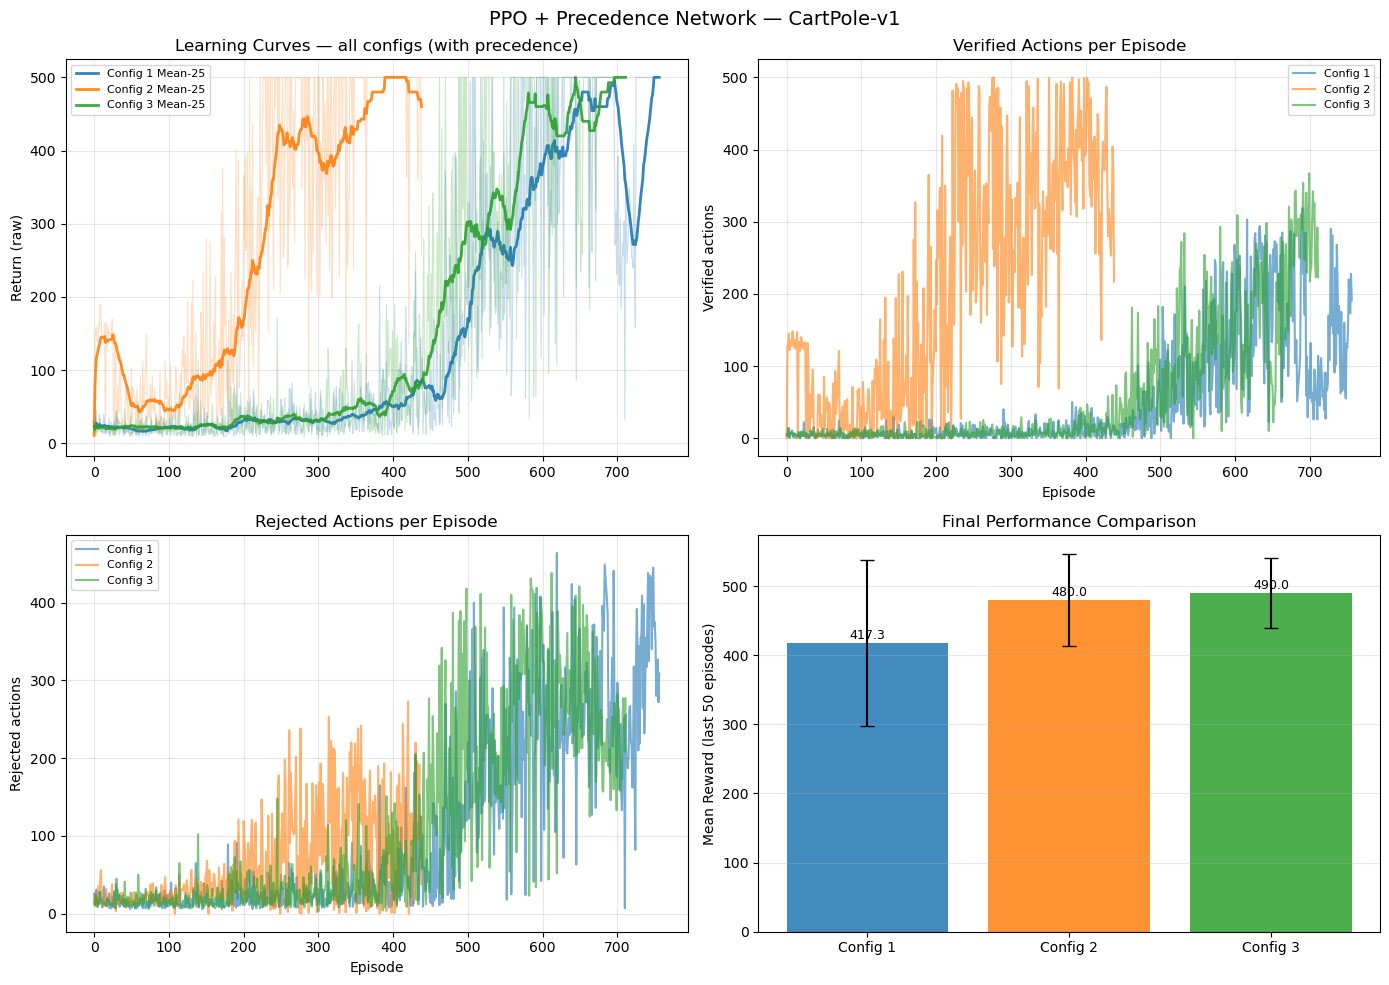

📊 Plot saved → plots_ppo_with_precedence/ppo_all_configs_with_precedence.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"PPO + Precedence Network — {ENV_NAME}", fontsize=14)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
valid  = [r for r in [results_config1, results_config2, results_config3]
          if r is not None]

ax = axes[0, 0]
for res, c in zip(valid, colors):
    ax.plot(res['rewards'],      alpha=0.25, color=c, linewidth=0.8)
    ax.plot(res['mean_rewards'], alpha=0.9,  color=c, linewidth=2.0,
            label=f"Config {res['config']} Mean-25")
ax.set_xlabel('Episode'); ax.set_ylabel('Return (raw)')
ax.set_title('Learning Curves — all configs (with precedence)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
for res, c in zip(valid, colors):
    ax.plot(res['verified'], alpha=0.6, color=c,
            label=f"Config {res['config']}")
ax.set_xlabel('Episode'); ax.set_ylabel('Verified actions')
ax.set_title('Verified Actions per Episode')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
for res, c in zip(valid, colors):
    ax.plot(res['skipped'], alpha=0.6, color=c,
            label=f"Config {res['config']}")
ax.set_xlabel('Episode'); ax.set_ylabel('Rejected actions')
ax.set_title('Rejected Actions per Episode')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
cfg_labels   = [f"Config {r['config']}" for r in valid]
final_means  = [np.mean(r['rewards'][-50:]) for r in valid]
final_stds   = [np.std( r['rewards'][-50:]) for r in valid]
bars = ax.bar(cfg_labels, final_means, color=colors[:len(valid)],
              yerr=final_stds, capsize=5, alpha=0.85)
for bar, val in zip(bars, final_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.1f}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Mean Reward (last 50 episodes)')
ax.set_title('Final Performance Comparison')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PLOT_DIR, 'ppo_all_configs_with_precedence.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved → {plot_path}")


## 14. Detailed Verification Analysis

In [14]:
print(f"\n{'='*80}")
print(f"  DETAILED VERIFICATION ANALYSIS — PPO")
print(f"{'='*80}\n")

for res in [results_config1, results_config2, results_config3]:
    if res is None:
        continue

    config = res['config']
    hist   = res['verification_history']

    print(f"\n📊 Config {config} Analysis:")
    print("-" * 80)

    if len(hist) > 0:
        safety_count   = sum(1 for v in hist if v.get('safety_ok',    False))
        stability_count= sum(1 for v in hist if v.get('stability_ok', False))
        invalid_count  = sum(1 for v in hist if not v.get('is_valid',  True))

        print(f"  Total verifications  : {len(hist)}")
        print(f"  - Safety passed      : {safety_count}  ({100*safety_count/len(hist):.1f}%)")
        print(f"  - Stability passed   : {stability_count}  ({100*stability_count/len(hist):.1f}%)")
        print(f"  - Total invalid      : {invalid_count}  ({100*invalid_count/len(hist):.1f}%)")

        pole_angles    = [v.get('pole_angle',    0) for v in hist]
        cart_positions = [v.get('cart_position', 0) for v in hist]
        print(f"\n  Predicted pole angles (mean±std)    : "
              f"{np.mean(pole_angles):.4f} ± {np.std(pole_angles):.4f}")
        print(f"  Predicted cart positions (mean±std) : "
              f"{np.mean(cart_positions):.4f} ± {np.std(cart_positions):.4f}")

    print(f"\n  Actions verified : {res['actions_verified']}")
    print(f"  Actions skipped  : {res['actions_skipped']}")

print(f"\n{'='*80}")



  DETAILED VERIFICATION ANALYSIS — PPO


📊 Config 1 Analysis:
--------------------------------------------------------------------------------
  Total verifications  : 120000
  - Safety passed      : 39081  (32.6%)
  - Stability passed   : 39081  (32.6%)
  - Total invalid      : 80919  (67.4%)

  Predicted pole angles (mean±std)    : 0.3527 ± 0.3288
  Predicted cart positions (mean±std) : 1.1886 ± 1.1860

  Actions verified : 39081
  Actions skipped  : 80919

📊 Config 2 Analysis:
--------------------------------------------------------------------------------
  Total verifications  : 120000
  - Safety passed      : 91366  (76.1%)
  - Stability passed   : 91366  (76.1%)
  - Total invalid      : 28634  (23.9%)

  Predicted pole angles (mean±std)    : 0.1865 ± 0.2976
  Predicted cart positions (mean±std) : 0.9519 ± 0.9611

  Actions verified : 91366
  Actions skipped  : 28634

📊 Config 3 Analysis:
--------------------------------------------------------------------------------
  Total ve

## 15. Save Results

In [ ]:
def save_results(results_list, filename):
    save_data = {}
    for res in results_list:
        if res is None:
            continue
        config = res['config']
        save_data[f"config_{config}"] = {
            'rewards'              : [float(r) for r in res['rewards']],
            'verified'             : [int(v)   for v in res['verified']],
            'skipped'              : [int(s)   for s in res['skipped']],
            'eval_rewards'         : [float(r) for r in res['eval_rewards']],
            'final_reward_mean'    : float(np.mean(res['rewards'][-50:])),
            'final_reward_std'     : float(np.std( res['rewards'][-50:])),
            'eval_mean'            : float(np.mean(res['eval_rewards'])),
            'total_verified'       : int(res['actions_verified']),
            'total_skipped'        : int(res['actions_skipped']),
        }
    out_path = os.path.join(CHECKPOINT_DIR, filename)
    with open(out_path, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"✅ Results saved → {out_path}")


save_results(
    [results_config1, results_config2, results_config3],
    'ppo_with_precedence_results.json'
)

for res in [results_config1, results_config2, results_config3]:
    if res is None:
        continue
    cfg_id = res['config']
    pth = os.path.join(CHECKPOINT_DIR, f"ppo_config{cfg_id}.pth")
    torch.save({
        "actor" : res['actor'].state_dict(),
        "critic": res['critic'].state_dict(),
        "state_mean": STATE_MEAN,  
        "state_std" : STATE_STD,  
    }, pth)
    print(f"✅ Model Config {cfg_id} saved → {pth}")

print(f"\n✅ All done!")
print(f"  Checkpoints : {CHECKPOINT_DIR}")
print(f"  Plots       : {PLOT_DIR}")


✅ Results saved → checkpoints_ppo_with_precedence/ppo_with_precedence_results.json
✅ Model Config 1 saved → checkpoints_ppo_with_precedence/ppo_config1.pth
✅ Model Config 2 saved → checkpoints_ppo_with_precedence/ppo_config2.pth
✅ Model Config 3 saved → checkpoints_ppo_with_precedence/ppo_config3.pth

✅ All done!
  Checkpoints : checkpoints_ppo_with_precedence
  Plots       : plots_ppo_with_precedence
